# Lab 04_2. Housing Price Prediction

실제 주택 데이터로 다중 선형회귀의 일반화 성능 확인하기

## 목표

- `housing.csv` 불러오기
- 입력 특성 12개와 목표값 `MEDV` 분리하기
- NumPy(넘파이, 수치 배열 처리 도구)로 훈련·테스트 데이터 나누기
- 훈련 데이터의 평균과 표준편차만 사용해 표준화하기
- `nn.Linear(12, 1)`로 주택가격 예측하기
- MAE(엠에이이, 평균절대오차)·RMSE(알엠에스이, 평균제곱근오차)·$R^2$(알 스퀘어, 결정계수) 계산하기
- 학습 적합도와 일반화 성능 구분하기

**훈련 성능은 학습 적합도를, 테스트 성능은 일반화 성능을 나타냅니다.**  
**Training performance shows model fit, while test performance shows generalization.**

## 실습 단계

### 1. 라이브러리 불러오기

In [6]:
from pathlib import Path

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

# 재현성: 난수 고정
np.random.seed(42)
torch.manual_seed(42)

print("PyTorch 버전:", torch.__version__)

PyTorch 버전: 2.13.0+cu130


### 2. `housing.csv` 불러오기

- 기본 경로: 현재 폴더의 `housing.csv`
- Colab(코랩, 웹 기반 파이썬 실습환경)에서 파일이 없으면 업로드 창 실행
- scikit-learn(사이킷런, 머신러닝 라이브러리)과 pandas(판다스, 표 데이터 처리 도구)는 사용하지 않음
- CSV(씨에스브이, 쉼표 구분 데이터)는 NumPy로 직접 읽음

In [7]:
data_path = Path("housing.csv")

# Colab에서 파일이 없으면 직접 업로드
if not data_path.exists():
    try:
        from google.colab import files

        uploaded_files = files.upload()
        if "housing.csv" not in uploaded_files:
            raise FileNotFoundError("housing.csv를 선택해 주세요.")
    except ImportError as error:
        raise FileNotFoundError(
            "현재 폴더에 housing.csv를 넣은 뒤 다시 실행해 주세요."
        ) from error

# 첫 줄의 열 이름을 포함해 CSV 읽기
housing_data = np.genfromtxt(
    data_path,
    delimiter=",",
    names=True,
    dtype=np.float32,
)

column_names = list(housing_data.dtype.names)

print("데이터 수:", len(housing_data))
print("열 이름:", column_names)

데이터 수: 506
열 이름: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']


### 3. 불러온 CSV 데이터 출력해 보기

데이터를 분리하거나 학습하기 전에 파일이 올바르게 읽혔는지 먼저 확인합니다.

- 열 이름 출력
- 앞부분 5행 출력
- 마지막 5행 출력
- 숫자 배열의 형상 확인

데이터 구조를 확인한 뒤에는 아래 출력문만 주석 처리해도 됩니다.

In [8]:
# 구조화 배열을 일반 2차원 배열로 변환
housing_preview = np.column_stack(
    [housing_data[name] for name in column_names]
)

# CSV 데이터 확인용 출력
# 전체 학습 흐름을 확인한 뒤에는 아래 3개 print 문을 주석 처리할 수 있음
print("CSV 열 이름:")
print(column_names)
print("\nCSV 앞부분 5행:")
print(housing_preview[:5])
print("\nCSV 마지막 5행:")
print(housing_preview[-5:])
print("\nCSV 숫자 배열 형상:", housing_preview.shape)

CSV 열 이름:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']

CSV 앞부분 5행:
[[6.3200e-03 1.8000e+01 2.3100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5200e+01 4.0900e+00 1.0000e+00 2.9600e+02 1.5300e+01 4.9800e+00
  2.4000e+01]
 [2.7310e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 6.4210e+00
  7.8900e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 9.1400e+00
  2.1600e+01]
 [2.7290e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 7.1850e+00
  6.1100e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 4.0300e+00
  3.4700e+01]
 [3.2370e-02 0.0000e+00 2.1800e+00 0.0000e+00 4.5800e-01 6.9980e+00
  4.5800e+01 6.0622e+00 3.0000e+00 2.2200e+02 1.8700e+01 2.9400e+00
  3.3400e+01]
 [6.9050e-02 0.0000e+00 2.1800e+00 0.0000e+00 4.5800e-01 7.1470e+00
  5.4200e+01 6.0622e+00 3.0000e+00 2.2200e+02 1.8700e+01 5.3300e+00
  3.6200e+01]]

CSV 마지막 5행:
[[6.2630e-02 0.0000e+00 1.1930e+01 0.0000e+00 5.7300e-01 6.5930e+00
  6.9100e+01 2.4786e+00 1.0000e+00 2.7300e+0

### 4. 입력 특성과 목표값 이해하기

입력 특성 12개:

- `CRIM`(크라임, 지역별 범죄율)
- `ZN`(지엔, 넓은 주거용 부지 비율)
- `INDUS`(인더스, 비소매 상업지역 비율)
- `CHAS`(채스, 찰스강 인접 여부)
- `NOX`(녹스, 질소산화물 농도)
- `RM`(알엠, 주택당 평균 방 수)
- `AGE`(에이지, 오래된 주택 비율)
- `DIS`(디아이에스, 고용 중심지까지의 거리)
- `RAD`(래드, 방사형 고속도로 접근성)
- `TAX`(택스, 재산세율)
- `PTRATIO`(피티레이쇼, 학생·교사 비율)
- `LSTAT`(엘스탯, 저소득 인구 비율)

목표값:

- `MEDV`(메드브이, 자가주택 가격 중앙값)
- 단위: 천 달러


In [9]:
feature_names = column_names[:-1]
target_name = column_names[-1]

# 입력 특성 12개를 열 방향으로 결합
x_all = np.column_stack(
    [housing_data[name] for name in feature_names]
).astype(np.float32)

# 목표값을 [데이터 수, 1] 형상으로 변환
y_all = housing_data[target_name].reshape(-1, 1).astype(np.float32)

print("입력 특성:", feature_names)
print("목표값:", target_name)
print("전체 입력 형상:", x_all.shape)
print("전체 목표 형상:", y_all.shape)
print("첫 번째 입력:", x_all[0])
print("첫 번째 목표값:", y_all[0, 0])

입력 특성: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT']
목표값: MEDV
전체 입력 형상: (506, 12)
전체 목표 형상: (506, 1)
첫 번째 입력: [6.320e-03 1.800e+01 2.310e+00 0.000e+00 5.380e-01 6.575e+00 6.520e+01
 4.090e+00 1.000e+00 2.960e+02 1.530e+01 4.980e+00]
첫 번째 목표값: 24.0


### 5. 훈련 데이터와 테스트 데이터 나누기

- 훈련 데이터 80%: 가중치와 편향 학습
- 테스트 데이터 20%: 학습에 사용하지 않은 주택의 가격 예측
- NumPy의 고정 난수 순열을 사용해 매번 같은 결과 재현

테스트 데이터는 모델 학습에 사용하지 않습니다.

In [10]:
# 인덱스를 무작위로 섞기
random_generator = np.random.default_rng(42)
shuffled_indices = random_generator.permutation(len(x_all))

# 훈련 80%·테스트 20%
train_count = int(len(x_all) * 0.8)
train_indices = shuffled_indices[:train_count]
test_indices = shuffled_indices[train_count:]

# NumPy 배열 분할
x_train_np = x_all[train_indices]
y_train_np = y_all[train_indices]
x_test_np = x_all[test_indices]
y_test_np = y_all[test_indices]

print("훈련 입력 형상:", x_train_np.shape)
print("훈련 목표 형상:", y_train_np.shape)
print("테스트 입력 형상:", x_test_np.shape)
print("테스트 목표 형상:", y_test_np.shape)

훈련 입력 형상: (404, 12)
훈련 목표 형상: (404, 1)
테스트 입력 형상: (102, 12)
테스트 목표 형상: (102, 1)


### 6. 훈련 데이터 기준으로 표준화하기

입력 특성마다 숫자의 범위가 크게 다릅니다.

- `CHAS`: 0 또는 1
- `TAX`: 수백 단위
- `CRIM`: 작은 소수부터 큰 값까지 분포

각 특성을 평균 0, 표준편차 1에 가까운 값으로 바꿉니다.

$$
x_{scaled}=\frac{x-\mu_{train}}{\sigma_{train}}
$$

목표값도 같은 방식으로 표준화해 학습을 안정화합니다.

$$
y_{scaled}=\frac{y-\mu_{y,train}}{\sigma_{y,train}}
$$

**테스트 데이터의 평균과 표준편차를 사용하면 안 됩니다.**  
테스트 정보를 학습 과정에 미리 사용하는 Data Leakage(데이터 리키지, 데이터 누출)가 발생하기 때문입니다.

In [11]:
# 훈련 데이터에서만 평균·표준편차 계산
x_mean = x_train_np.mean(axis=0)
x_std = x_train_np.std(axis=0)
y_mean = y_train_np.mean(axis=0)
y_std = y_train_np.std(axis=0)

# 0으로 나누는 상황 방지
x_std = np.where(x_std == 0, 1.0, x_std)

# 훈련 통계량으로 훈련·테스트 데이터 모두 표준화
x_train_scaled_np = (x_train_np - x_mean) / x_std
x_test_scaled_np = (x_test_np - x_mean) / x_std
y_train_scaled_np = (y_train_np - y_mean) / y_std

print("표준화된 훈련 입력 평균:")
print(np.round(x_train_scaled_np.mean(axis=0), 4))
print("표준화된 훈련 입력 표준편차:")
print(np.round(x_train_scaled_np.std(axis=0), 4))

표준화된 훈련 입력 평균:
[-0. -0. -0. -0.  0.  0. -0. -0. -0.  0. -0.  0.]
표준화된 훈련 입력 표준편차:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 7. NumPy 배열을 PyTorch 텐서로 바꾸기

- 입력 형상: `[데이터 수, 12]`
- 목표 형상: `[데이터 수, 1]`
- 자료형: `float32`

In [12]:
x_train = torch.from_numpy(x_train_scaled_np).float()
y_train = torch.from_numpy(y_train_scaled_np).float()
x_test = torch.from_numpy(x_test_scaled_np).float()
y_test = torch.from_numpy(y_test_np).float()

print("훈련 입력 텐서:", x_train.shape, x_train.dtype)
print("훈련 목표 텐서:", y_train.shape, y_train.dtype)
print("테스트 입력 텐서:", x_test.shape, x_test.dtype)
print("테스트 목표 텐서:", y_test.shape, y_test.dtype)

훈련 입력 텐서: torch.Size([404, 12]) torch.float32
훈련 목표 텐서: torch.Size([404, 1]) torch.float32
테스트 입력 텐서: torch.Size([102, 12]) torch.float32
테스트 목표 텐서: torch.Size([102, 1]) torch.float32


### 8. 주택가격 예측 모델 정의하기

`Lab 04_1`의 모델에서 입력 특성 수만 확장합니다.

- 이전 모델: `nn.Linear(3, 1)`
- 변경 모델: `nn.Linear(12, 1)`

$$
\hat{y}=w_1x_1+w_2x_2+\cdots+w_{12}x_{12}+b
$$

`nn.Linear(12, 1)`은 12개의 가중치와 1개의 편향을 학습합니다.

In [13]:
class HousingPriceRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        # (변경) 입력 특성 12개 → 주택가격 1개
        self.linear = nn.Linear(12, 1)

    def forward(self, x):
        # 순전파
        prediction = self.linear(x)
        return prediction


model = HousingPriceRegressionModel()

print(model)
print("가중치 형상:", model.linear.weight.shape)
print("편향 형상:", model.linear.bias.shape)

HousingPriceRegressionModel(
  (linear): Linear(in_features=12, out_features=1, bias=True)
)
가중치 형상: torch.Size([1, 12])
편향 형상: torch.Size([1])


### 9. 손실함수와 최적화 도구 정의하기

- 학습 손실: `nn.MSELoss()`(엔엔 엠에스이 로스, 평균제곱오차 손실함수)
- 최적화 도구: `SGD`(에스지디, 확률적 경사하강법)
- 학습 대상: `model.parameters()`

MSE(엠에스이, 평균제곱오차)는 큰 오차에 더 큰 벌점을 주므로 모델 학습에 사용합니다.

In [14]:
# 손실함수
loss_function = nn.MSELoss()

# 최적화 도구
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

### 10. 모델 학습하기

1. 훈련 데이터 순전파
2. MSE 손실 계산
3. 기울기 초기화
4. 역전파
5. 가중치와 편향 갱신

테스트 데이터는 이 과정에 들어가지 않습니다.

In [15]:
epochs = 3000
loss_history = []

model.train()

for epoch in range(epochs):
    # 훈련 데이터 순전파·손실
    train_prediction_scaled = model(x_train)
    loss = loss_function(train_prediction_scaled, y_train)

    # 기울기 초기화·역전파·갱신
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 손실 기록
    loss_history.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch + 1:4d}/{epochs}, "
            f"MSE Loss: {loss.item():.6f}"
        )

Epoch  500/3000, MSE Loss: 0.271581
Epoch 1000/3000, MSE Loss: 0.271556
Epoch 1500/3000, MSE Loss: 0.271556
Epoch 2000/3000, MSE Loss: 0.271556
Epoch 2500/3000, MSE Loss: 0.271556
Epoch 3000/3000, MSE Loss: 0.271556


### 11. 손실 변화 확인하기

학습이 진행될수록 표준화된 목표값의 MSE 손실이 감소하는지 확인합니다.

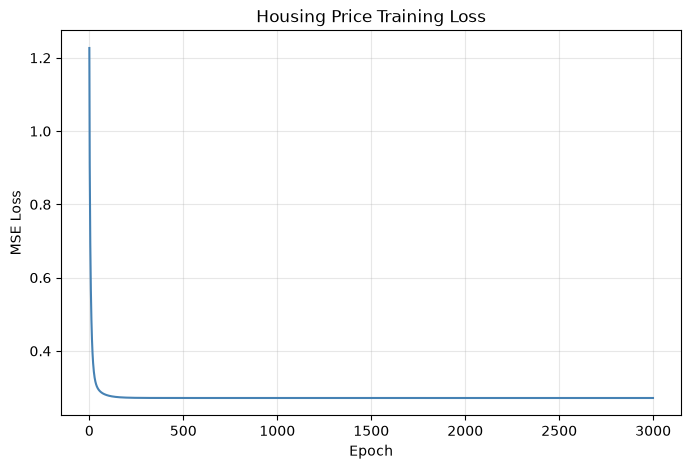

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Housing Price Training Loss")
plt.grid(alpha=0.3)
plt.show()

### 12. 테스트 데이터 예측하기

모델 출력은 표준화된 가격입니다.  
훈련 목표값의 평균과 표준편차를 사용해 천 달러 단위로 복원합니다.

$$
\hat{y}=\hat{y}_{scaled}\sigma_{y,train}+\mu_{y,train}
$$

In [17]:
model.eval()

with torch.no_grad():
    # 훈련·테스트 데이터 예측
    train_prediction_scaled = model(x_train)
    test_prediction_scaled = model(x_test)

    # 실제 가격 단위로 복원
    y_mean_tensor = torch.tensor(y_mean, dtype=torch.float32)
    y_std_tensor = torch.tensor(y_std, dtype=torch.float32)

    train_prediction = (
        train_prediction_scaled * y_std_tensor + y_mean_tensor
    )
    test_prediction = (
        test_prediction_scaled * y_std_tensor + y_mean_tensor
    )

    # 훈련 목표값도 실제 가격 단위로 준비
    y_train_actual = torch.from_numpy(y_train_np).float()

print("테스트 예측 형상:", test_prediction.shape)
print("테스트 실제값 5개:", y_test[:5].squeeze().numpy())
print("테스트 예측값 5개:", np.round(test_prediction[:5].squeeze().numpy(), 2))

테스트 예측 형상: torch.Size([102, 1])
테스트 실제값 5개: [16.3 33.1 26.6 19.5 32. ]
테스트 예측값 5개: [12.74 34.12 22.27 19.03 33.21]


### 13. 평가 지표 계산하기

#### MAE(엠에이이, 평균절대오차)

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

- 실제 가격과 예측 가격 차이의 절댓값 평균
- 단위: 천 달러
- 평균적으로 가격을 얼마나 틀리는지 직관적으로 표시
- 작을수록 좋음

#### RMSE(알엠에스이, 평균제곱근오차)

$$
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

- 큰 오차에 더 민감한 지표
- 단위: 천 달러
- MAE보다 많이 크면 일부 주택의 예측 오차가 크다는 의미
- 작을수록 좋음

#### $R^2$(알 스퀘어, 결정계수)

$$
R^2=1-\frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}
$$

- 모델이 주택가격의 변화를 얼마나 설명하는지 표시
- 1에 가까울수록 설명력이 높음
- 0이면 평균값만 예측하는 수준
- 음수이면 평균값 예측보다도 성능이 낮음

MAE와 RMSE는 오차의 크기를, $R^2$는 데이터 변화의 설명 정도를 나타냅니다.

In [18]:
def calculate_metrics(y_true, y_pred):
    # 평균절대오차
    mae = torch.mean(torch.abs(y_true - y_pred))

    # 평균제곱근오차
    rmse = torch.sqrt(torch.mean((y_true - y_pred) ** 2))

    # 결정계수
    residual_sum = torch.sum((y_true - y_pred) ** 2)
    total_sum = torch.sum((y_true - torch.mean(y_true)) ** 2)
    r2 = 1 - residual_sum / total_sum

    return mae.item(), rmse.item(), r2.item()


# 훈련 데이터 적합도
train_mae, train_rmse, train_r2 = calculate_metrics(
    y_train_actual,
    train_prediction,
)

# 테스트 데이터 일반화 성능
test_mae, test_rmse, test_r2 = calculate_metrics(
    y_test,
    test_prediction,
)

print("[훈련 데이터: 학습 적합도]")
print(f"MAE  : {train_mae:.3f} 천 달러")
print(f"RMSE : {train_rmse:.3f} 천 달러")
print(f"R²   : {train_r2:.3f}")

print("\n[테스트 데이터: 일반화 성능]")
print(f"MAE  : {test_mae:.3f} 천 달러")
print(f"RMSE : {test_rmse:.3f} 천 달러")
print(f"R²   : {test_r2:.3f}")

[훈련 데이터: 학습 적합도]
MAE  : 3.455 천 달러
RMSE : 4.815 천 달러
R²   : 0.728

[테스트 데이터: 일반화 성능]
MAE  : 2.992 천 달러
RMSE : 4.473 천 달러
R²   : 0.751


### 14. 학습 적합도와 일반화 성능 구분하기

훈련 데이터 결과:

- 모델이 이미 본 데이터를 얼마나 잘 설명하는지 확인
- 학습 적합도 확인
- 훈련 성능만 좋다고 실제 예측 성능이 좋은 것은 아님

테스트 데이터 결과:

- 모델이 학습 중 보지 않은 데이터를 얼마나 잘 예측하는지 확인
- 일반화 성능 확인
- 실제 활용 가능성을 판단할 때 더 중요

해석 기준:

- 훈련·테스트 오차가 모두 큼 → Underfitting(언더피팅, 과소적합) 가능성
- 훈련 오차는 작고 테스트 오차만 큼 → Overfitting(오버피팅, 과적합) 가능성
- 두 결과가 비슷함 → 학습한 관계가 새로운 데이터에도 비교적 유지됨
- 테스트 성능이 조금 더 좋을 수도 있음 → 우연히 테스트 묶음이 더 쉬울 수 있으며, 테스트 성능이 항상 더 좋다는 뜻은 아님

데이터를 한 번만 나눈 결과이므로 절대적인 성능 판정이 아니라 실습용 비교 기준으로 사용합니다.

In [19]:
# 훈련·테스트 성능 차이
rmse_gap = test_rmse - train_rmse
r2_gap = train_r2 - test_r2

print(f"RMSE 차이(테스트 - 훈련): {rmse_gap:.3f}")
print(f"R² 차이(훈련 - 테스트): {r2_gap:.3f}")

if test_rmse > train_rmse * 1.3:
    print("해석: 테스트 오차 증가가 커서 과적합 가능성을 점검합니다.")
else:
    print("해석: 훈련과 테스트 오차 사이에 큰 급증은 없습니다.")

RMSE 차이(테스트 - 훈련): -0.343
R² 차이(훈련 - 테스트): -0.023
해석: 훈련과 테스트 오차 사이에 큰 급증은 없습니다.


### 15. 실제값과 예측값 비교하기

- 점이 대각선에 가까울수록 예측이 정확함
- 점이 대각선에서 멀수록 예측 오차가 큼
- 테스트 데이터만 사용해 일반화 결과를 시각화

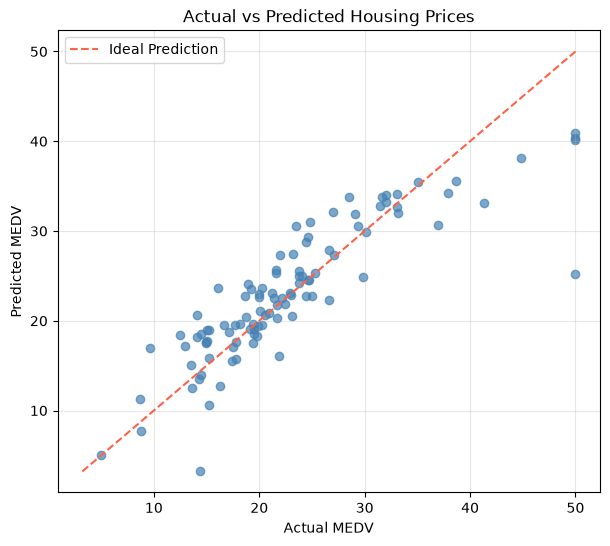

In [20]:
actual_test_values = y_test.squeeze().numpy()
predicted_test_values = test_prediction.squeeze().numpy()

price_min = min(actual_test_values.min(), predicted_test_values.min())
price_max = max(actual_test_values.max(), predicted_test_values.max())

plt.figure(figsize=(7, 6))
plt.scatter(
    actual_test_values,
    predicted_test_values,
    alpha=0.7,
    color="steelblue",
)
plt.plot(
    [price_min, price_max],
    [price_min, price_max],
    color="tomato",
    linestyle="--",
    label="Ideal Prediction",
)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted Housing Prices")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 16. 잔차 확인하기

Residual(리주얼, 잔차)은 실제값에서 예측값을 뺀 값입니다.

- 잔차가 0에 가까움 → 예측이 정확함
- 잔차가 양수 → 실제 가격보다 낮게 예측
- 잔차가 음수 → 실제 가격보다 높게 예측
- 특정 모양이 반복됨 → 직선 모델이 설명하지 못한 관계가 있을 수 있음

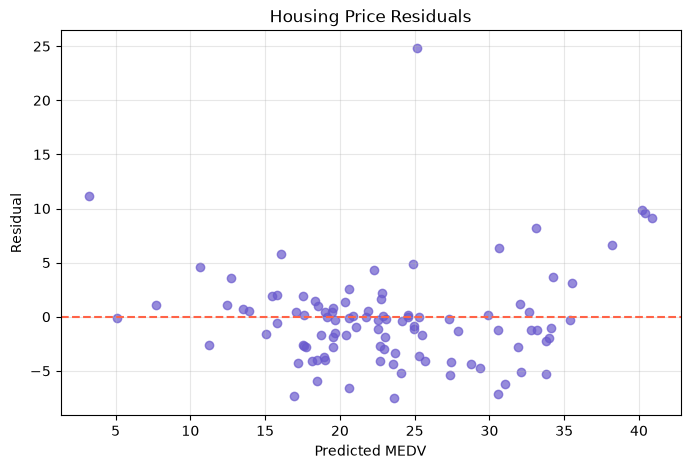

In [21]:
test_residuals = actual_test_values - predicted_test_values

plt.figure(figsize=(8, 5))
plt.scatter(
    predicted_test_values,
    test_residuals,
    alpha=0.7,
    color="slateblue",
)
plt.axhline(0, color="tomato", linestyle="--")
plt.xlabel("Predicted MEDV")
plt.ylabel("Residual")
plt.title("Housing Price Residuals")
plt.grid(alpha=0.3)
plt.show()

### 17. 실제 단위의 가중치 확인하기

표준화된 모델의 가중치를 원래 입력 단위와 가격 단위로 변환합니다.

- 절댓값이 큰 가중치: 다른 조건이 같을 때 예측값 변화가 큼
- 가중치의 부호: 예측 가격과의 증가·감소 방향
- 특성 사이의 상관관계가 있으므로 가중치를 곧바로 원인으로 해석하면 안 됨

In [22]:
# 표준화된 모델 매개변수
scaled_weights = (
    model.linear.weight.detach().cpu().numpy().reshape(-1)
)
scaled_bias = model.linear.bias.detach().cpu().item()

# 실제 단위의 가중치와 편향
real_weights = scaled_weights * y_std.item() / x_std
real_bias = (
    y_mean.item()
    + y_std.item() * scaled_bias
    - np.sum(real_weights * x_mean)
)

# 영향 크기 확인을 위해 절댓값 기준 정렬
weight_order = np.argsort(np.abs(real_weights))[::-1]

print("실제 단위의 편향:", round(real_bias, 4))
print("절댓값이 큰 가중치부터 확인:")

for index in weight_order:
    print(f"{feature_names[index]:8s}: {real_weights[index]: .4f}")

실제 단위의 편향: 42.6051
절댓값이 큰 가중치부터 확인:
NOX     : -18.5378
RM      :  3.4803
CHAS    :  1.8626
DIS     : -1.4294
PTRATIO : -0.9323
LSTAT   : -0.5549
RAD     :  0.3373
CRIM    : -0.1271
ZN      :  0.0503
TAX     : -0.0148
AGE     :  0.0084
INDUS   :  0.0058


## 확인 실습

테스트 데이터 중 첫 번째 주택의 특성 12개를 모델에 입력합니다.

- 실제 가격과 예측 가격 비교
- 오차의 방향과 크기 확인
- 단위: 천 달러

In [23]:
sample_index = 0
sample_actual = y_test[sample_index].item()
sample_prediction = test_prediction[sample_index].item()
sample_error = sample_actual - sample_prediction

print("입력 특성:")

for name, value in zip(feature_names, x_test_np[sample_index]):
    print(f"{name:8s}: {value:.4f}")

print(f"\n실제 가격: {sample_actual:.2f} 천 달러")
print(f"예측 가격: {sample_prediction:.2f} 천 달러")
print(f"잔차      : {sample_error:.2f} 천 달러")

입력 특성:
CRIM    : 28.6558
ZN      : 0.0000
INDUS   : 18.1000
CHAS    : 0.0000
NOX     : 0.5970
RM      : 5.1550
AGE     : 100.0000
DIS     : 1.5894
RAD     : 24.0000
TAX     : 666.0000
PTRATIO : 20.2000
LSTAT   : 20.0800

실제 가격: 16.30 천 달러
예측 가격: 12.74 천 달러
잔차      : 3.56 천 달러


## 실행 확인

아래 셀에서 오류가 없으면 `Lab 04_2`가 정상적으로 완료된 것입니다.

In [24]:
assert len(housing_data) == 506
assert len(feature_names) == 12
assert target_name == "MEDV"
assert x_all.shape == (506, 12)
assert y_all.shape == (506, 1)
assert x_train.shape == torch.Size([404, 12])
assert y_train.shape == torch.Size([404, 1])
assert x_test.shape == torch.Size([102, 12])
assert y_test.shape == torch.Size([102, 1])
assert model.linear.weight.shape == torch.Size([1, 12])
assert model.linear.bias.shape == torch.Size([1])
assert train_prediction.shape == torch.Size([404, 1])
assert test_prediction.shape == torch.Size([102, 1])
assert np.isfinite(test_mae)
assert np.isfinite(test_rmse)
assert np.isfinite(test_r2)

print("Lab 04_2 실행 확인 완료")

Lab 04_2 실행 확인 완료


## 핵심 정리

- 데이터: `housing.csv`의 주택 데이터 506개
- 입력 특성: `CRIM`부터 `LSTAT`까지 12개
- 목표값: `MEDV` 주택가격 중앙값
- 데이터 분할: NumPy 고정 난수로 훈련 404개·테스트 102개
- 표준화: 훈련 데이터의 평균과 표준편차만 사용
- 모델: `nn.Linear(12, 1)`
- 손실함수: `nn.MSELoss()`
- 최적화 도구: `SGD`
- 학습 적합도: 훈련 데이터의 MAE·RMSE·$R^2$
- 일반화 성능: 테스트 데이터의 MAE·RMSE·$R^2$
- 시각화: 실제값·예측값 비교와 잔차 확인
- 주의: 테스트 데이터는 학습과 표준화 통계 계산에 사용하지 않음
